# Production full-band peakfinder batch timing

This notebook validates a completed clean/no-candidate batch-timing campaign before plotting it. Edit `RESULTS_DIR` below, or set `PIRATE_PEAKFINDER_BATCH_TIMING_RESULTS`. Raw iteration points are shown where readable; curves and heatmaps use medians with interquartile spread.

In [ ]:
import csv
import json
import math
import os
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

SCHEMA_NAME = 'pirate-peakfinder-batch-timing'
EXPECTED_SHAPES = [(4096, 128), (1024, 64), (2048, 64), (1024, 64), (1024, 32), (2048, 32), (512, 32), (1024, 32), (1024, 16), (2048, 16)]
EXPECTED_PRIMARY = [0, 1, 1, 2, 2, 2, 3, 3, 3, 3]
EXPECTED_EARLY = [0, 1, 0, 2, 1, 0, 3, 2, 1, 0]
EXPECTED_PIXELS_PER_BEAM = 983_040
SUMMARY_METRICS = (
    'total_beams_peakfinding_wall_ms',
    'peakfinding_ms_per_beam',
    'equivalent_ms_per_batch',
    'beam_chunks_per_second',
    'realtime_beam_capacity',
    'load_fraction_for_total_beams',
)

# Editable result location. The environment variable takes precedence.
RESULTS_DIR = Path(os.environ.get(
    'PIRATE_PEAKFINDER_BATCH_TIMING_RESULTS',
    'peakfinder_tests/results_peakfinder_batch_timing',
)).expanduser()
if not RESULTS_DIR.is_dir() and Path.cwd().name == 'peakfinder_tests':
    RESULTS_DIR = Path('results_peakfinder_batch_timing')

paths = {name: RESULTS_DIR / name for name in (
    'timings.csv', 'summary.csv', 'tree_diagnostics.csv', 'metadata.yaml'
)}
missing = [str(path) for path in paths.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(f'missing benchmark files: {missing}')

def read_csv(path):
    with path.open(newline='') as stream:
        reader = csv.DictReader(stream)
        fields = tuple(reader.fieldnames or ())
        if not fields or len(fields) != len(set(fields)):
            raise ValueError(f'{path}: missing or duplicate CSV columns')
        rows = list(reader)
    if not rows:
        raise ValueError(f'{path}: result table is empty')
    return fields, rows

timing_fields, timings = read_csv(paths['timings.csv'])
summary_fields, summaries = read_csv(paths['summary.csv'])
tree_fields, tree_rows = read_csv(paths['tree_diagnostics.csv'])
with paths['metadata.yaml'].open() as stream:
    metadata = yaml.safe_load(stream) or {}

TIMING_REQUIRED = {
    'schema_version', 'campaign_id', 'iteration', 'base_seed', 'device',
    'method', 'dm_reach', 'beam_batch_size', 'actual_batch_sizes',
    'final_batch_size', 'n_batches', 'total_beams', 'threshold',
    'waist_bins', 'warmup', 'total_pixels_per_beam',
    'total_input_pixels', 'total_candidates', 'chunk_duration_ms',
    'total_beams_peakfinding_wall_ms', 'peakfinding_ms_per_beam',
    'equivalent_ms_per_batch', 'beam_chunks_per_second',
    'realtime_beam_capacity', 'load_fraction_for_total_beams',
}
SUMMARY_REQUIRED = {
    'schema_version', 'campaign_id', 'dm_reach', 'beam_batch_size',
    'completed_iterations',
} | {
    f'{metric}_{statistic}'
    for metric in SUMMARY_METRICS
    for statistic in ('median', 'minimum', 'maximum', 'q25', 'q75', 'iqr')
}
TREE_REQUIRED = {
    'schema_version', 'campaign_id', 'dm_reach', 'beam_batch_size',
    'n_batches', 'tree_index',
    'primary_tree_index', 'early_trigger_level', 'ndm', 'ntime',
    'pixels_per_beam', 'dm_radius', 'active_footprint_cells', 'time_radius',
    'left_time_radius', 'right_time_radius', 'halo_columns',
    'required_priming_calls', 'regular_batch_size', 'final_batch_size',
    'regular_work_shape', 'final_work_shape',
}
for name, fields, required in (
    ('timings.csv', timing_fields, TIMING_REQUIRED),
    ('summary.csv', summary_fields, SUMMARY_REQUIRED),
    ('tree_diagnostics.csv', tree_fields, TREE_REQUIRED),
):
    missing_columns = required - set(fields)
    if missing_columns:
        raise ValueError(f'{name}: missing columns {sorted(missing_columns)}')

def integer(value, context):
    try:
        result = int(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f'{context}: expected integer, got {value!r}') from exc
    return result

def finite(value, context):
    try:
        result = float(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f'{context}: expected number, got {value!r}') from exc
    if not np.isfinite(result):
        raise ValueError(f'{context}: expected finite number, got {value!r}')
    return result

def required_alias(mapping, names, context):
    for name in names:
        if name in mapping:
            return mapping[name]
    raise ValueError(f'{context}: missing one of {names}')

def close(observed, expected, context):
    if not np.isclose(float(observed), float(expected), rtol=1e-9, atol=1e-9):
        raise ValueError(f'{context}: observed {observed!r}, expected {expected!r}')

if metadata.get('schema_name') != SCHEMA_NAME:
    raise ValueError(f'metadata.yaml: expected schema {SCHEMA_NAME!r}')
if integer(metadata.get('schema_version'), 'metadata.yaml:schema_version') != 1:
    raise ValueError('metadata.yaml: unsupported schema version')
required_metadata_sections = {
    'campaign_id', 'campaign_signature', 'authoritative_config',
    'authoritative_plan', 'inputs', 'parameters', 'batching',
    'peakfinder_geometry', 'steady_state', 'timing', 'gpu', 'software',
    'git', 'outputs', 'progress',
}
if not required_metadata_sections <= set(metadata):
    raise ValueError(f'metadata.yaml: missing sections {sorted(required_metadata_sections - set(metadata))}')
if metadata.get('campaign_complete') is not True:
    raise ValueError('metadata.yaml: benchmark campaign is incomplete')
meta_campaign = metadata.get('campaign_id')
if meta_campaign is None and isinstance(metadata.get('campaign'), dict):
    meta_campaign = metadata['campaign'].get('campaign_id', metadata['campaign'].get('id'))
if not isinstance(meta_campaign, str) or not meta_campaign:
    raise ValueError('metadata.yaml: missing campaign_id')
signature = metadata.get('campaign_signature')
if not isinstance(signature, str) or len(signature) != 64:
    raise ValueError('metadata.yaml: invalid campaign signature')
benchmark_meta = metadata.get('parameters')
plan_meta = metadata.get('authoritative_plan')
if not isinstance(benchmark_meta, dict) or not isinstance(plan_meta, dict):
    raise ValueError('metadata.yaml: missing benchmark/plan sections')
shape_values = required_alias(plan_meta, ('tree_shapes_ndm_ntime', 'tree_shapes'), 'metadata.yaml:plan')
meta_shapes = [tuple(map(int, shape)) for shape in shape_values]
if meta_shapes != EXPECTED_SHAPES:
    raise ValueError(f'metadata.yaml: unexpected tree shapes {meta_shapes}')
meta_pixels = integer(required_alias(
    plan_meta, ('pixels_per_beam', 'total_pixels_per_beam_chunk', 'total_pixels_per_beam'),
    'metadata.yaml:plan'), 'metadata.yaml:total pixels')
if meta_pixels != EXPECTED_PIXELS_PER_BEAM:
    raise ValueError('metadata.yaml: total pixels per beam is not 983,040')
dm_grid = tuple(map(int, required_alias(
    benchmark_meta, ('dm_reach_values', 'dm_reaches'), 'metadata.yaml:benchmark')))
batch_grid = tuple(map(int, required_alias(
    benchmark_meta, ('beam_batch_sizes', 'batch_sizes'), 'metadata.yaml:benchmark')))
if not dm_grid or len(dm_grid) != len(set(dm_grid)) or min(dm_grid) < 0:
    raise ValueError('metadata.yaml: invalid dm_reach grid')
if not batch_grid or len(batch_grid) != len(set(batch_grid)) or min(batch_grid) < 1:
    raise ValueError('metadata.yaml: invalid beam-batch grid')
total_beams = integer(required_alias(benchmark_meta, ('total_beams',), 'metadata.yaml:benchmark'), 'metadata total_beams')
iterations = integer(required_alias(
    benchmark_meta, ('iterations', 'timed_iterations'), 'metadata.yaml:benchmark'), 'metadata iterations')
threshold = finite(required_alias(benchmark_meta, ('threshold',), 'metadata.yaml:benchmark'), 'metadata threshold')
waist_bins = integer(required_alias(benchmark_meta, ('waist_bins',), 'metadata.yaml:benchmark'), 'metadata waist_bins')
warmup = integer(required_alias(benchmark_meta, ('warmup', 'warmup_calls'), 'metadata.yaml:benchmark'), 'metadata warmup')
chunk_duration_ms = finite(required_alias(
    plan_meta, ('chunk_duration_ms',), 'metadata.yaml:plan'), 'metadata chunk duration')
if total_beams < 1 or iterations < 1 or warmup < 0:
    raise ValueError('metadata.yaml: invalid beam/iteration/warm-up counts')
config_document = metadata['authoritative_config']['document']
expected_chunk_duration_ms = (
    finite(config_document['time_sample_ms'], 'config time_sample_ms')
    * integer(config_document['time_samples_per_chunk'], 'config time_samples_per_chunk')
)
close(chunk_duration_ms, expected_chunk_duration_ms, 'metadata chunk duration')
base_seed = integer(required_alias(metadata.get('inputs', {}), ('base_seed',), 'metadata.yaml:inputs'), 'metadata base_seed')
device = integer(required_alias(benchmark_meta, ('device',), 'metadata.yaml:parameters'), 'metadata device')
if required_alias(benchmark_meta, ('method',), 'metadata.yaml:parameters') != 'full_band':
    raise ValueError('metadata.yaml: method is not full_band')
inputs_meta = metadata.get('inputs', {})
if inputs_meta.get('noise_model') != 'gaussian_white_noise_no_corruption' or inputs_meta.get('corruption') != 'none':
    raise ValueError('metadata.yaml: inputs are not the clean Gaussian baseline')
if inputs_meta.get('generation_dtype') != 'float32' or inputs_meta.get('production_snr_dtype') != 'float16':
    raise ValueError('metadata.yaml: input dtype policy is inconsistent')
outputs_meta = metadata.get('outputs')
if not isinstance(outputs_meta, dict):
    raise ValueError('metadata.yaml: missing output schema manifest')
for filename, fields in (
    ('timings.csv', timing_fields), ('summary.csv', summary_fields),
    ('tree_diagnostics.csv', tree_fields),
):
    if outputs_meta.get(filename) != list(fields):
        raise ValueError(f'metadata.yaml: {filename} schema disagrees with the CSV')
batching_meta = metadata.get('batching')
if not isinstance(batching_meta, dict) or not isinstance(batching_meta.get('partitions'), dict):
    raise ValueError('metadata.yaml: missing beam partition audit')
if set(batching_meta['partitions']) != {str(value) for value in batch_grid}:
    raise ValueError('metadata.yaml: partition grid disagrees with requested batch sizes')
for batch in batch_grid:
    partition = batching_meta['partitions'][str(batch)]
    expected_sizes = [min(batch, total_beams - start) for start in range(0, total_beams, batch)]
    expected_ids = [list(range(start, min(start + batch, total_beams))) for start in range(0, total_beams, batch)]
    if partition.get('actual_batch_sizes') != expected_sizes or partition.get('beam_ids') != expected_ids:
        raise ValueError(f'metadata.yaml: batch size {batch} does not cover IDs 0..{total_beams - 1} exactly once')
    if integer(partition.get('n_batches'), f'metadata batch {batch}:n_batches') != len(expected_sizes):
        raise ValueError(f'metadata.yaml: batch size {batch} has inconsistent n_batches')
progress_meta = metadata.get('progress', {})
expected_rows = len(dm_grid) * len(batch_grid) * iterations
if integer(progress_meta.get('expected_timing_rows'), 'metadata progress expected rows') != expected_rows:
    raise ValueError('metadata.yaml: expected timing-row count is inconsistent')
if integer(progress_meta.get('completed_timing_rows'), 'metadata progress completed rows') != expected_rows:
    raise ValueError('metadata.yaml: completed timing-row count is inconsistent')

timing_by_key = {}
for lineno, row in enumerate(timings, start=2):
    context = f'timings.csv:{lineno}'
    if integer(row['schema_version'], context + ':schema_version') != 1:
        raise ValueError(f'{context}: unsupported schema version')
    if row['campaign_id'] != meta_campaign:
        raise ValueError(f'{context}: campaign_id disagrees with metadata')
    if row['method'] != 'full_band':
        raise ValueError(f'{context}: benchmark did not use the production full_band method')
    if integer(row['base_seed'], context + ':base_seed') != base_seed:
        raise ValueError(f'{context}: base_seed disagrees with metadata')
    if integer(row['device'], context + ':device') != device:
        raise ValueError(f'{context}: device disagrees with metadata')
    dm = integer(row['dm_reach'], context + ':dm_reach')
    batch = integer(row['beam_batch_size'], context + ':beam_batch_size')
    iteration = integer(row['iteration'], context + ':iteration')
    key = (dm, batch, iteration)
    if key in timing_by_key:
        raise ValueError(f'{context}: duplicate timing key {key}')
    timing_by_key[key] = row
    if dm not in dm_grid or batch not in batch_grid or not 0 <= iteration < iterations:
        raise ValueError(f'{context}: row is outside the requested campaign grid')
    if integer(row['total_beams'], context + ':total_beams') != total_beams:
        raise ValueError(f'{context}: total_beams disagrees with metadata')
    if integer(row['total_pixels_per_beam'], context + ':pixels per beam') != EXPECTED_PIXELS_PER_BEAM:
        raise ValueError(f'{context}: pixels per beam is not 983,040')
    if integer(row['waist_bins'], context + ':waist_bins') != waist_bins:
        raise ValueError(f'{context}: waist_bins disagrees with metadata')
    if integer(row['warmup'], context + ':warmup') != warmup:
        raise ValueError(f'{context}: warmup disagrees with metadata')
    close(finite(row['threshold'], context + ':threshold'), threshold, context + ':threshold')
    close(finite(row['chunk_duration_ms'], context + ':chunk duration'), chunk_duration_ms, context + ':chunk duration')
    actual = json.loads(row['actual_batch_sizes'])
    if not isinstance(actual, list) or not actual or any(integer(value, context + ':actual_batch_sizes') < 1 for value in actual):
        raise ValueError(f'{context}: invalid actual_batch_sizes')
    actual = [int(value) for value in actual]
    expected_actual = [
        min(batch, total_beams - start)
        for start in range(0, total_beams, batch)
    ]
    if actual != expected_actual or sum(actual) != total_beams:
        raise ValueError(f'{context}: beam partition does not cover each beam exactly once')
    if integer(row['n_batches'], context + ':n_batches') != len(actual):
        raise ValueError(f'{context}: n_batches disagrees with partition')
    if integer(row['final_batch_size'], context + ':final_batch_size') != actual[-1]:
        raise ValueError(f'{context}: final batch size disagrees with partition')
    if integer(row['total_input_pixels'], context + ':total_input_pixels') != total_beams * EXPECTED_PIXELS_PER_BEAM:
        raise ValueError(f'{context}: total input pixel count is inconsistent')
    if integer(row['total_candidates'], context + ':total_candidates') != 0:
        raise ValueError(f'{context}: clean benchmark produced candidates')
    wall = finite(row['total_beams_peakfinding_wall_ms'], context + ':wall')
    if wall <= 0:
        raise ValueError(f'{context}: authoritative wall time must be positive')
    expected_derived = {
        'peakfinding_ms_per_beam': wall / total_beams,
        'equivalent_ms_per_batch': wall / len(actual),
        'beam_chunks_per_second': 1000.0 * total_beams / wall,
        'realtime_beam_capacity': chunk_duration_ms * total_beams / wall,
        'load_fraction_for_total_beams': wall / chunk_duration_ms,
    }
    for field, expected in expected_derived.items():
        observed = finite(row[field], context + ':' + field)
        if observed < 0:
            raise ValueError(f'{context}: negative {field}')
        close(observed, expected, context + ':' + field)

expected_timing_keys = {
    (dm, batch, iteration)
    for dm in dm_grid for batch in batch_grid for iteration in range(iterations)
}
if set(timing_by_key) != expected_timing_keys:
    missing_keys = sorted(expected_timing_keys - set(timing_by_key))
    extra_keys = sorted(set(timing_by_key) - expected_timing_keys)
    raise ValueError(f'timings.csv: incomplete campaign; missing={missing_keys[:5]}, extra={extra_keys[:5]}')

summary_by_key = {}
for lineno, row in enumerate(summaries, start=2):
    context = f'summary.csv:{lineno}'
    if integer(row['schema_version'], context + ':schema_version') != 1:
        raise ValueError(f'{context}: unsupported schema version')
    if row['campaign_id'] != meta_campaign:
        raise ValueError(f'{context}: campaign_id disagrees with metadata')
    key = (integer(row['dm_reach'], context), integer(row['beam_batch_size'], context))
    if key in summary_by_key:
        raise ValueError(f'{context}: duplicate summary key {key}')
    summary_by_key[key] = row
    if key[0] not in dm_grid or key[1] not in batch_grid:
        raise ValueError(f'{context}: summary row is outside the campaign grid')
    if integer(row['completed_iterations'], context + ':completed_iterations') != iterations:
        raise ValueError(f'{context}: completed iteration count is inconsistent')
    for metric in SUMMARY_METRICS:
        names = [f'{metric}_{statistic}' for statistic in (
            'minimum', 'q25', 'median', 'q75', 'maximum', 'iqr'
        )]
        values = np.asarray([finite(row[name], context + ':' + name) for name in names])
        if np.any(values < 0):
            raise ValueError(f'{context}: negative summary statistic for {metric}')
        if not values[0] <= values[1] <= values[2] <= values[3] <= values[4]:
            raise ValueError(f'{context}: summary quantiles are unordered for {metric}')
        close(values[5], values[3] - values[1], context + ':' + metric + '_iqr')

if set(summary_by_key) != {(dm, batch) for dm in dm_grid for batch in batch_grid}:
    raise ValueError('summary.csv: configuration grid is incomplete')

for dm in dm_grid:
    for batch in batch_grid:
        raw_group = [timing_by_key[(dm, batch, iteration)] for iteration in range(iterations)]
        for metric in SUMMARY_METRICS:
            key = (dm, batch)
            values = np.asarray([finite(row[metric], f'timings:{key}:{metric}') for row in raw_group])
            q25, q75 = np.percentile(values, [25.0, 75.0])
            expected = {
                'median': np.median(values), 'minimum': np.min(values),
                'maximum': np.max(values), 'q25': q25, 'q75': q75,
                'iqr': q75 - q25,
            }
            for field, value in expected.items():
                name = f'{metric}_{field}'
                close(finite(summary_by_key[key][name], f'summary:{key}:{name}'), value, f'summary:{key}:{name}')

trees_by_key = defaultdict(list)
for lineno, row in enumerate(tree_rows, start=2):
    context = f'tree_diagnostics.csv:{lineno}'
    if integer(row['schema_version'], context + ':schema_version') != 1:
        raise ValueError(f'{context}: unsupported schema version')
    if row['campaign_id'] != meta_campaign:
        raise ValueError(f'{context}: campaign_id disagrees with metadata')
    key = (integer(row['dm_reach'], context), integer(row['beam_batch_size'], context))
    if key[0] not in dm_grid or key[1] not in batch_grid:
        raise ValueError(f'{context}: diagnostic row is outside campaign grid')
    trees_by_key[key].append(row)

expected_tree_keys = {(dm, batch) for dm in dm_grid for batch in batch_grid}
if set(trees_by_key) != expected_tree_keys:
    raise ValueError('tree_diagnostics.csv: configuration grid is incomplete')
for key, group in trees_by_key.items():
    dm, batch = key
    group.sort(key=lambda row: integer(row['tree_index'], f'trees:{key}:tree'))
    if [integer(row['tree_index'], f'trees:{key}:tree') for row in group] != list(range(10)):
        raise ValueError(f'tree_diagnostics.csv:{key}: expected exactly trees 0..9')
    shapes = [(integer(row['ndm'], f'trees:{key}:ndm'), integer(row['ntime'], f'trees:{key}:ntime')) for row in group]
    if shapes != EXPECTED_SHAPES:
        raise ValueError(f'tree_diagnostics.csv:{key}: unexpected ragged shapes')
    if [integer(row['primary_tree_index'], f'trees:{key}:primary') for row in group] != EXPECTED_PRIMARY:
        raise ValueError(f'tree_diagnostics.csv:{key}: primary-tree indices changed')
    if [integer(row['early_trigger_level'], f'trees:{key}:early') for row in group] != EXPECTED_EARLY:
        raise ValueError(f'tree_diagnostics.csv:{key}: early-trigger levels changed')
    if sum(integer(row['pixels_per_beam'], f'trees:{key}:pixels') for row in group) != EXPECTED_PIXELS_PER_BEAM:
        raise ValueError(f'tree_diagnostics.csv:{key}: per-tree pixels do not sum to 983,040')
    expected_partition = [min(batch, total_beams - start) for start in range(0, total_beams, batch)]
    for tree_index, row in enumerate(group):
        if integer(row['n_batches'], f'trees:{key}:n_batches') != len(expected_partition):
            raise ValueError(f'tree_diagnostics.csv:{key}: n_batches disagrees with partition')
        ndm, ntime = shapes[tree_index]
        if integer(row['pixels_per_beam'], f'trees:{key}:pixels') != ndm * ntime:
            raise ValueError(f'tree_diagnostics.csv:{key}: tree pixel count mismatch')
        active = integer(row['active_footprint_cells'], f'trees:{key}:active')
        dm_radius = integer(row['dm_radius'], f'trees:{key}:dm radius')
        radius = integer(row['time_radius'], f'trees:{key}:radius')
        left = integer(row['left_time_radius'], f'trees:{key}:left')
        right = integer(row['right_time_radius'], f'trees:{key}:right')
        halo = integer(row['halo_columns'], f'trees:{key}:halo')
        priming = integer(row['required_priming_calls'], f'trees:{key}:priming')
        if active < 1 or min(dm_radius, radius, left, right, halo, priming) < 0:
            raise ValueError(f'tree_diagnostics.csv:{key}: invalid footprint/halo value')
        if dm_radius != dm or active > (2 * dm_radius + 1) * (left + right + 1):
            raise ValueError(f'tree_diagnostics.csv:{key}: footprint extent is inconsistent')
        if left > radius or right > radius or halo != 2 * radius:
            raise ValueError(f'tree_diagnostics.csv:{key}: active extent exceeds the retained temporal halo')
        if priming != max(1, halo // ntime + 1):
            raise ValueError(f'tree_diagnostics.csv:{key}: priming depth does not fill the halo')
        regular = integer(row['regular_batch_size'], f'trees:{key}:regular batch')
        final = integer(row['final_batch_size'], f'trees:{key}:final batch')
        if regular != expected_partition[0] or final != expected_partition[-1]:
            raise ValueError(f'tree_diagnostics.csv:{key}: batch dimensions disagree with partition')
        regular_shape = tuple(map(int, json.loads(row['regular_work_shape'])))
        final_shape = tuple(map(int, json.loads(row['final_work_shape'])))
        if regular_shape != (regular, ndm, ntime + halo):
            raise ValueError(f'tree_diagnostics.csv:{key}: regular work shape is inconsistent')
        if final_shape != (final, ndm, ntime + halo):
            raise ValueError(f'tree_diagnostics.csv:{key}: final work shape is inconsistent')

geometry_meta = metadata.get('peakfinder_geometry')
if not isinstance(geometry_meta, list):
    raise ValueError('metadata.yaml: peakfinder_geometry must be a list')
geometry_by_key = {}
for entry in geometry_meta:
    key = (integer(entry.get('dm_reach'), 'metadata geometry dm'), integer(entry.get('tree_index'), 'metadata geometry tree'))
    if key in geometry_by_key:
        raise ValueError(f'metadata.yaml: duplicate peakfinder geometry {key}')
    geometry_by_key[key] = entry
if set(geometry_by_key) != {(dm, tree) for dm in dm_grid for tree in range(10)}:
    raise ValueError('metadata.yaml: peakfinder geometry grid is incomplete')
for dm in dm_grid:
    for tree_index in range(10):
        csv_row = trees_by_key[(dm, batch_grid[0])][tree_index]
        meta_row = geometry_by_key[(dm, tree_index)]
        for field in ('dm_radius', 'active_footprint_cells', 'left_time_radius', 'right_time_radius', 'time_radius', 'halo_columns'):
            if integer(csv_row[field], f'tree csv {dm},{tree_index}:{field}') != integer(meta_row.get(field), f'metadata geometry {dm},{tree_index}:{field}'):
                raise ValueError(f'metadata/CSV geometry mismatch at dm_reach={dm}, tree={tree_index}, field={field}')

for dm in dm_grid:
    for tree_index in range(10):
        fingerprints = set()
        for batch in batch_grid:
            row = trees_by_key[(dm, batch)][tree_index]
            fingerprints.add(tuple(row[name] for name in (
                'ndm', 'ntime', 'active_footprint_cells', 'time_radius',
                'left_time_radius', 'right_time_radius', 'halo_columns', 'required_priming_calls'
            )))
        if len(fingerprints) != 1:
            raise ValueError(f'tree geometry changed with batch size for dm_reach={dm}, tree={tree_index}')

print(f'Validated {len(timings)} raw iterations, {len(summaries)} summary rows, and {len(tree_rows)} tree diagnostics.')
print(f'Campaign {meta_campaign}: {total_beams} beams, {len(dm_grid)} DM reaches, {len(batch_grid)} batch sizes, {iterations} iterations/configuration.')


In [2]:
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25})
colors = {dm: plt.cm.viridis(index / max(len(dm_grid) - 1, 1)) for index, dm in enumerate(dm_grid)}
batch_colors = {batch: plt.cm.turbo(index / max(len(batch_grid) - 1, 1)) for index, batch in enumerate(batch_grid)}

def raw_values(dm, batch, metric):
    return np.asarray([float(timing_by_key[(dm, batch, iteration)][metric]) for iteration in range(iterations)])

def summary_value(dm, batch, metric, statistic='median'):
    return float(summary_by_key[(dm, batch)][f'{metric}_{statistic}'])

def curve_with_raw(ax, x_values, fixed_values, metric, *, label, color, x_is_dm):
    medians, q25, q75 = [], [], []
    for x, fixed in zip(x_values, fixed_values):
        dm, batch = (x, fixed) if x_is_dm else (fixed, x)
        values = raw_values(dm, batch, metric)
        jitter_scale = 0.012 * max(float(x), 1.0)
        offsets = np.linspace(-jitter_scale, jitter_scale, len(values)) if len(values) > 1 else np.zeros(1)
        ax.scatter(np.full(len(values), x) + offsets, values, s=13, alpha=0.30, color=color)
        medians.append(summary_value(dm, batch, metric, 'median'))
        q25.append(summary_value(dm, batch, metric, 'q25'))
        q75.append(summary_value(dm, batch, metric, 'q75'))
    x_values = np.asarray(x_values, dtype=float)
    ax.fill_between(x_values, q25, q75, color=color, alpha=0.13)
    ax.plot(x_values, medians, marker='o', linewidth=1.6, color=color, label=label)

def median_matrix(metric):
    return np.asarray([[summary_value(dm, batch, metric) for batch in batch_grid] for dm in dm_grid])

plot_helpers_ready = True


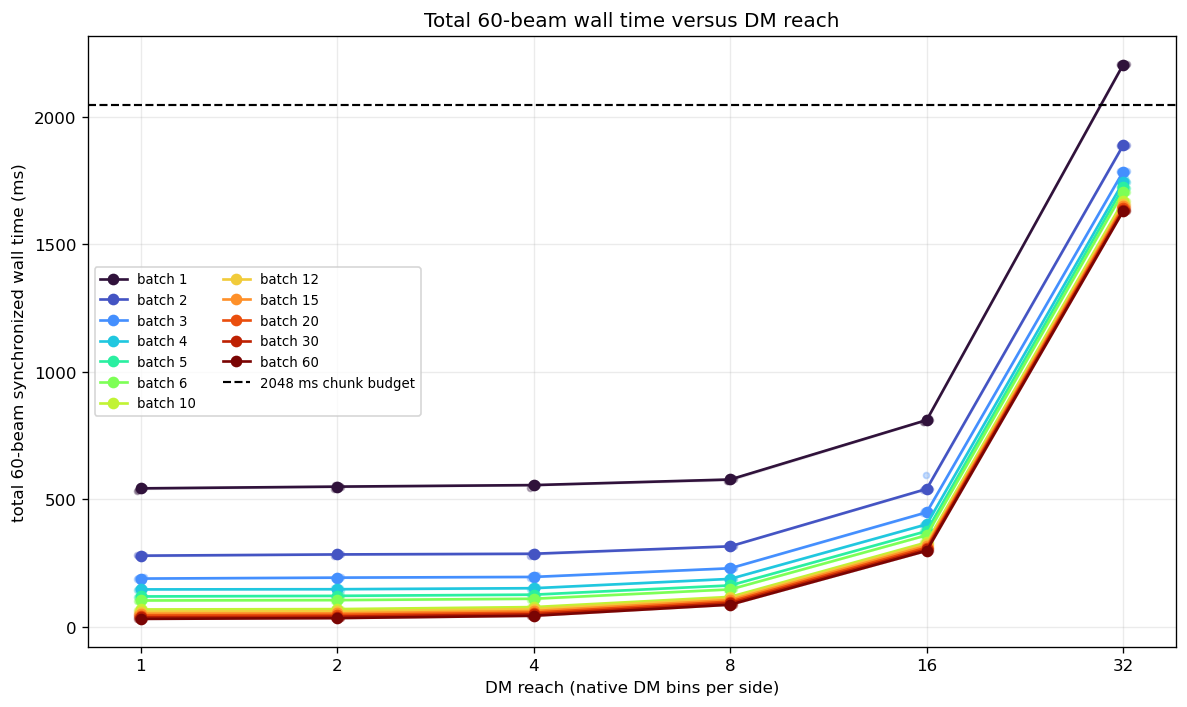

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
for batch in batch_grid:
    curve_with_raw(
        ax, dm_grid, [batch] * len(dm_grid), 'total_beams_peakfinding_wall_ms',
        label=f'batch {batch}', color=batch_colors[batch], x_is_dm=True,
    )
ax.axhline(chunk_duration_ms, color='black', linestyle='--', linewidth=1.3, label=f'{chunk_duration_ms:g} ms chunk budget')
ax.set_xscale('log', base=2)
ax.set_xticks(dm_grid, [str(value) for value in dm_grid])
ax.set_xlabel('DM reach (native DM bins per side)')
ax.set_ylabel(f'total {total_beams}-beam synchronized wall time (ms)')
ax.set_title(f'Total {total_beams}-beam wall time versus DM reach')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


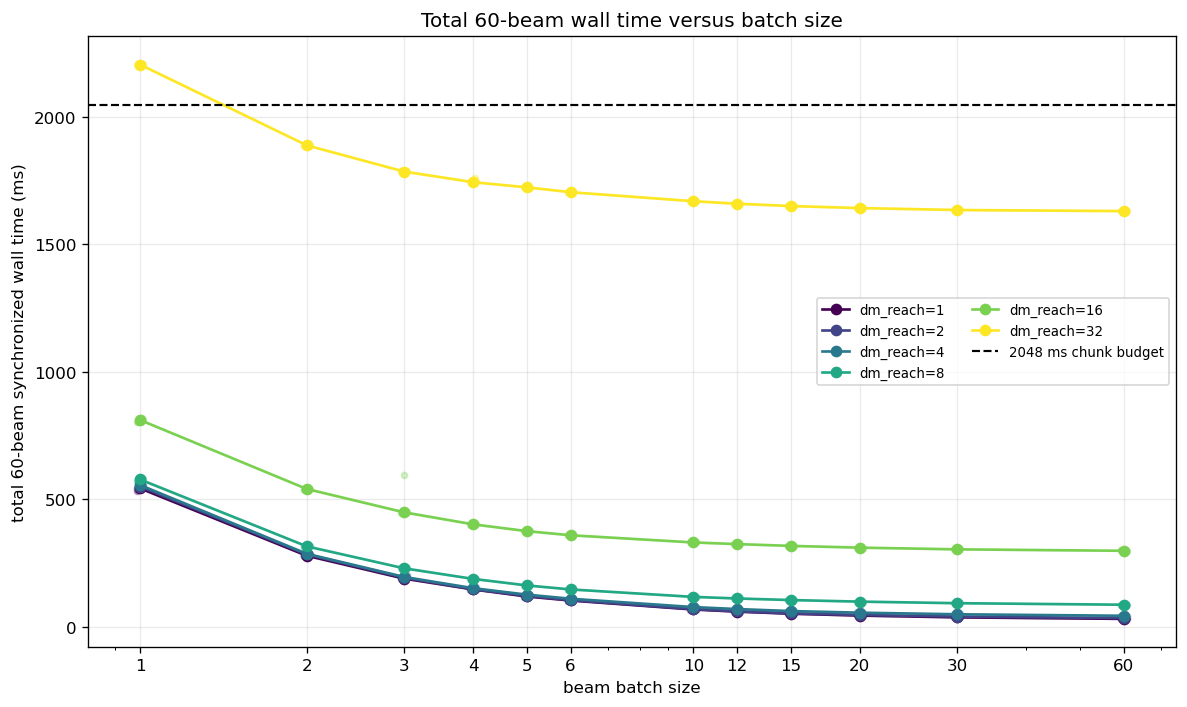

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
for dm in dm_grid:
    curve_with_raw(
        ax, batch_grid, [dm] * len(batch_grid), 'total_beams_peakfinding_wall_ms',
        label=f'dm_reach={dm}', color=colors[dm], x_is_dm=False,
    )
ax.axhline(chunk_duration_ms, color='black', linestyle='--', linewidth=1.3, label=f'{chunk_duration_ms:g} ms chunk budget')
ax.set_xscale('log')
ax.set_xticks(batch_grid, [str(value) for value in batch_grid])
ax.set_xlabel('beam batch size')
ax.set_ylabel(f'total {total_beams}-beam synchronized wall time (ms)')
ax.set_title(f'Total {total_beams}-beam wall time versus batch size')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


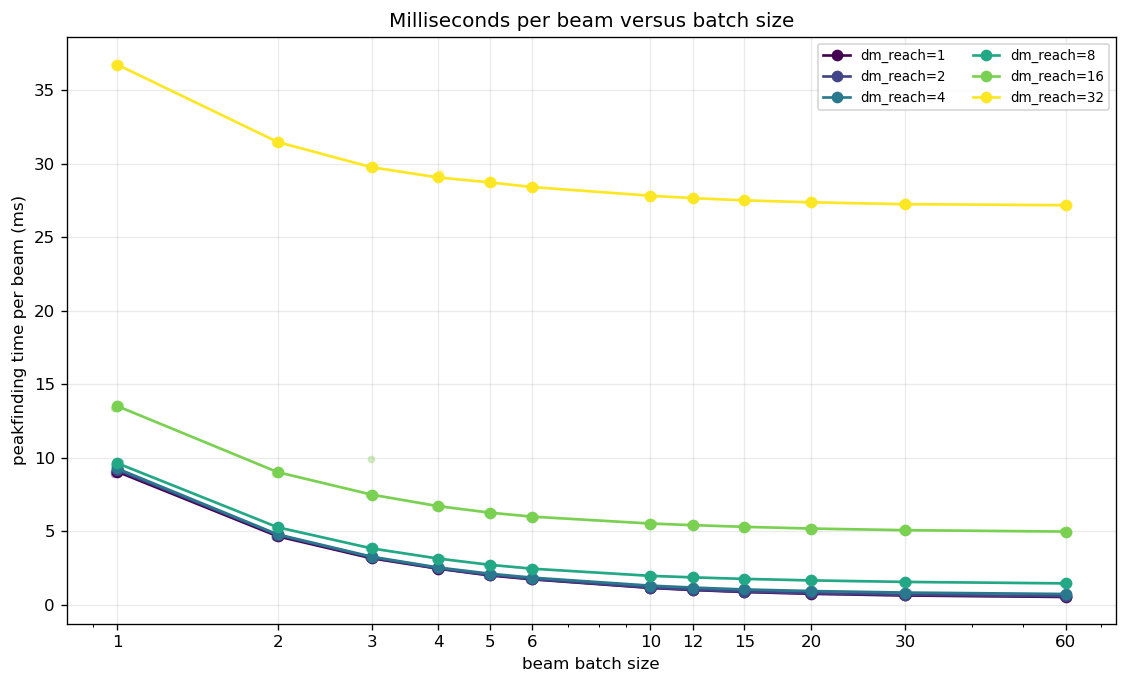

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5.8))
for dm in dm_grid:
    curve_with_raw(
        ax, batch_grid, [dm] * len(batch_grid), 'peakfinding_ms_per_beam',
        label=f'dm_reach={dm}', color=colors[dm], x_is_dm=False,
    )
ax.set_xscale('log')
ax.set_xticks(batch_grid, [str(value) for value in batch_grid])
ax.set_xlabel('beam batch size')
ax.set_ylabel('peakfinding time per beam (ms)')
ax.set_title('Milliseconds per beam versus batch size')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


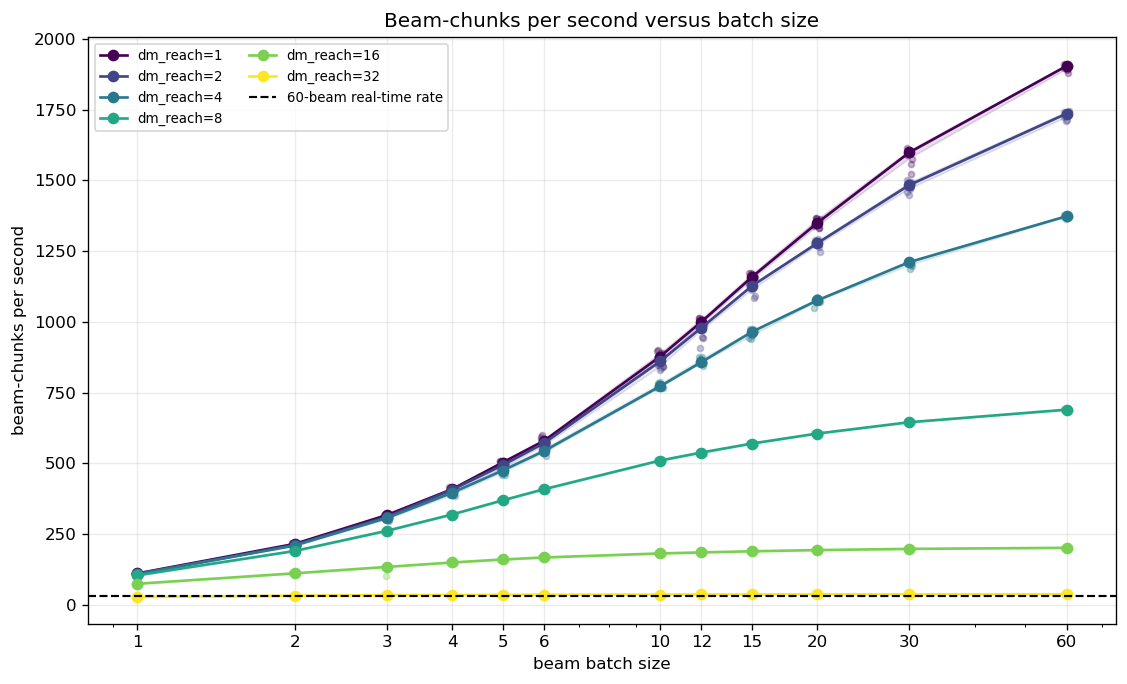

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.8))
for dm in dm_grid:
    curve_with_raw(
        ax, batch_grid, [dm] * len(batch_grid), 'beam_chunks_per_second',
        label=f'dm_reach={dm}', color=colors[dm], x_is_dm=False,
    )
required_rate = 1000.0 * total_beams / chunk_duration_ms
ax.axhline(required_rate, color='black', linestyle='--', linewidth=1.3, label=f'{total_beams}-beam real-time rate')
ax.set_xscale('log')
ax.set_xticks(batch_grid, [str(value) for value in batch_grid])
ax.set_xlabel('beam batch size')
ax.set_ylabel('beam-chunks per second')
ax.set_title('Beam-chunks per second versus batch size')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


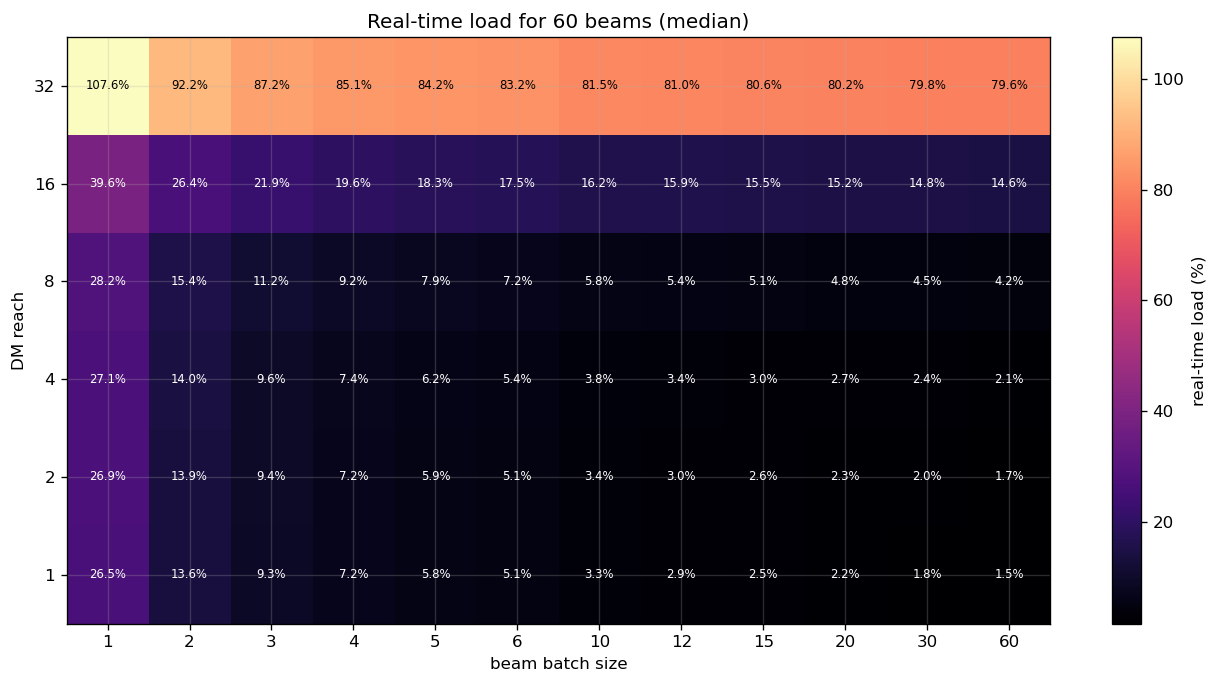

In [7]:
load_percent = 100.0 * median_matrix('load_fraction_for_total_beams')
fig, ax = plt.subplots(figsize=(11, 5.8))
image = ax.imshow(
    load_percent, aspect='auto', origin='lower', cmap='magma',
    interpolation='nearest',
)
for row_index, dm in enumerate(dm_grid):
    for column_index, batch in enumerate(batch_grid):
        value = load_percent[row_index, column_index]
        red, green, blue, _ = image.cmap(image.norm(value))
        luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
        text_color = 'black' if luminance > 0.55 else 'white'
        ax.text(
            column_index, row_index, f'{value:.1f}%',
            ha='center', va='center', fontsize=7, color=text_color,
        )
ax.set_xticks(range(len(batch_grid)), [str(value) for value in batch_grid])
ax.set_yticks(range(len(dm_grid)), [str(value) for value in dm_grid])
ax.set_xlabel('beam batch size')
ax.set_ylabel('DM reach')
ax.set_title(f'Real-time load for {total_beams} beams (median)')
fig.colorbar(image, ax=ax, label='real-time load (%)')
fig.tight_layout()
plt.show()


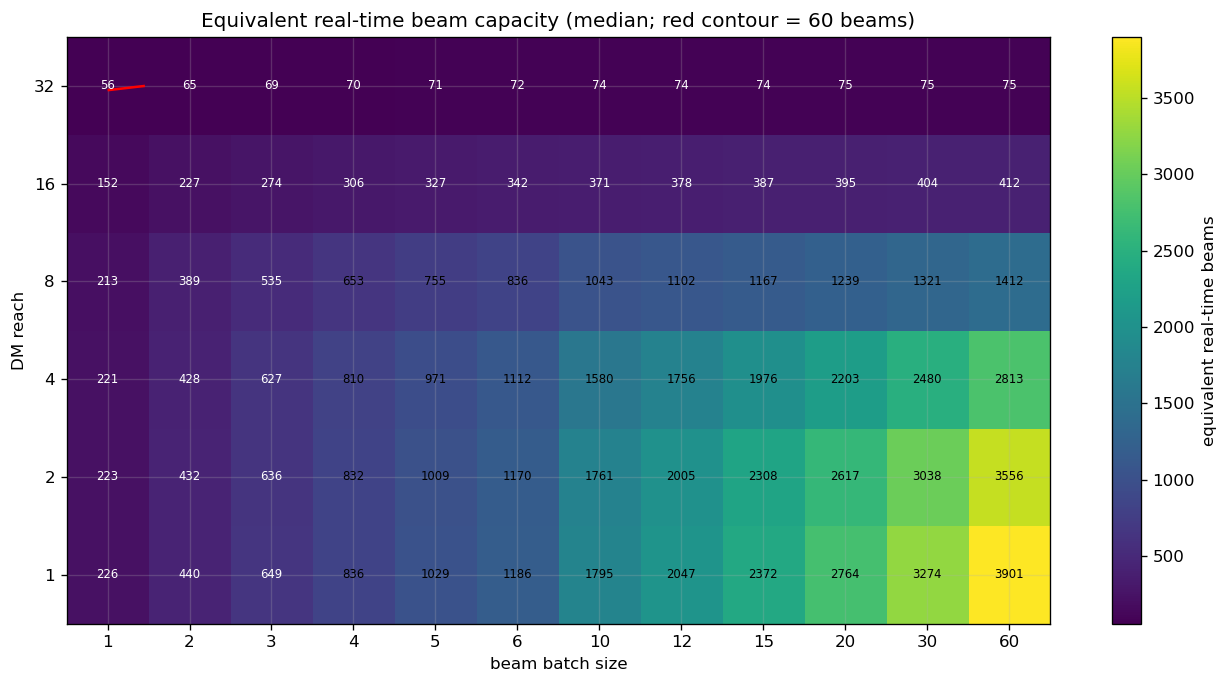

In [8]:
capacity = median_matrix('realtime_beam_capacity')
fig, ax = plt.subplots(figsize=(11, 5.8))
image = ax.imshow(capacity, aspect='auto', origin='lower', cmap='viridis')
for row_index, dm in enumerate(dm_grid):
    for column_index, batch in enumerate(batch_grid):
        ax.text(column_index, row_index, f'{capacity[row_index, column_index]:.0f}', ha='center', va='center', fontsize=7, color='white' if capacity[row_index, column_index] < np.nanmedian(capacity) else 'black')
if np.nanmin(capacity) <= total_beams <= np.nanmax(capacity):
    ax.contour(capacity, levels=[total_beams], colors='red', linewidths=1.5)
ax.set_xticks(range(len(batch_grid)), [str(value) for value in batch_grid])
ax.set_yticks(range(len(dm_grid)), [str(value) for value in dm_grid])
ax.set_xlabel('beam batch size')
ax.set_ylabel('DM reach')
ax.set_title(f'Equivalent real-time beam capacity (median; red contour = {total_beams} beams)')
fig.colorbar(image, ax=ax, label='equivalent real-time beams')
fig.tight_layout()
plt.show()


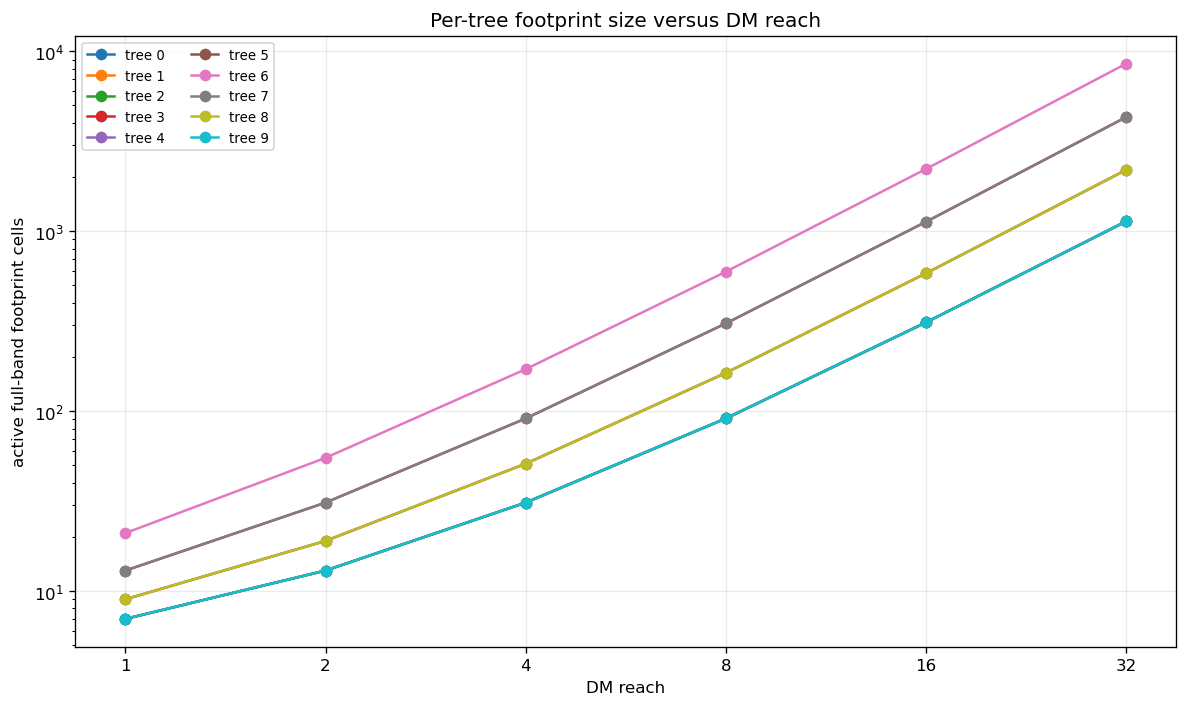

In [9]:
diagnostic_batch = batch_grid[0]
fig, ax = plt.subplots(figsize=(10, 6))
for tree_index in range(10):
    values = [int(trees_by_key[(dm, diagnostic_batch)][tree_index]['active_footprint_cells']) for dm in dm_grid]
    ax.plot(dm_grid, values, marker='o', linewidth=1.5, label=f'tree {tree_index}')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(dm_grid, [str(value) for value in dm_grid])
ax.set_xlabel('DM reach')
ax.set_ylabel('active full-band footprint cells')
ax.set_title('Per-tree footprint size versus DM reach')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


In [10]:
print('Fastest median batch size for each DM reach')
print('dm_reach  batch  wall_ms  ms_per_beam  load_percent  realtime_beam_capacity')
for dm in dm_grid:
    best_batch = min(batch_grid, key=lambda batch: summary_value(dm, batch, 'total_beams_peakfinding_wall_ms'))
    print(
        f'{dm:8d}  {best_batch:5d}  '
        f'{summary_value(dm, best_batch, "total_beams_peakfinding_wall_ms"):7.3f}  '
        f'{summary_value(dm, best_batch, "peakfinding_ms_per_beam"):11.4f}  '
        f'{100.0 * summary_value(dm, best_batch, "load_fraction_for_total_beams"):12.2f}  '
        f'{summary_value(dm, best_batch, "realtime_beam_capacity"):22.1f}'
    )

diagnostic_field = next((name for name in (
    'peakfinder_gpu_diagnostic_ms', 'process_chunk_gpu_diagnostic_ms',
    'diagnostic_gpu_ms',
) if name in tree_fields), None)
if diagnostic_field is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    for tree_index in range(10):
        values = [float(trees_by_key[(dm, diagnostic_batch)][tree_index][diagnostic_field]) for dm in dm_grid]
        ax.plot(dm_grid, values, marker='o', label=f'tree {tree_index}')
    ax.set_xscale('log', base=2)
    ax.set_xticks(dm_grid, [str(value) for value in dm_grid])
    ax.set_xlabel('DM reach')
    ax.set_ylabel('diagnostic CUDA-event time (ms)')
    ax.set_title(f'Optional per-tree diagnostic timing (batch size {diagnostic_batch}; not authoritative wall time)')
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print('No optional per-tree GPU diagnostic timing column was recorded.')


Fastest median batch size for each DM reach
dm_reach  batch  wall_ms  ms_per_beam  load_percent  realtime_beam_capacity
       1     60   31.503       0.5251          1.54                  3900.5
       2     60   34.559       0.5760          1.69                  3555.7
       4     60   43.689       0.7282          2.13                  2812.6
       8     60   87.028       1.4505          4.25                  1412.0
      16     60  298.462       4.9744         14.57                   411.7
      32     60  1630.193      27.1699         79.60                    75.4
No optional per-tree GPU diagnostic timing column was recorded.
